# 🌊 Flood Prediction System using Machine Learning

## Model Training

**Project:** Rising Waters – Flood Prediction

### Objective

The objective of this notebook is to train and evaluate multiple machine learning classification algorithms for flood prediction.

The trained models will be compared using standard evaluation metrics such as accuracy score, confusion matrix, and classification report. The best-performing model will then be selected and saved for deployment in the Flask web application.

# Step 1: Import Required Libraries

In this step, we import all the necessary libraries required for building, training, evaluating, and saving machine learning models.

The imported libraries will be used for:

- Loading and manipulating the dataset
- Splitting the dataset into training and testing sets
- Scaling numerical features
- Building multiple machine learning models
- Evaluating model performance
- Saving the final trained model for deployment

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# We'll decide whether to use GradientBoostingClassifier or XGBClassifier
# when we reach that step.

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Model Saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Step 2: Load the Dataset

The flood prediction dataset is loaded into the notebook using the Pandas library.

The dataset contains meteorological features such as temperature, humidity, cloud cover, annual rainfall, seasonal rainfall, and subdivision information, which are used to predict flood occurrences.

After loading the dataset, the first few records are displayed to verify that the data has been imported successfully.

In [2]:
# Load the dataset
dataset = pd.read_excel("../dataset/flood_dataset.xlsx")

# Display first five records
dataset.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


# Step 3: Prepare Features and Target Variable

Machine learning models require the dataset to be separated into:

- **Features (X):** Independent variables used for prediction.
- **Target Variable (y):** Dependent variable representing whether a flood occurs.

In this project, the **flood** column is the target variable, while all remaining columns are used as input features.

In [3]:
# Separate features and target variable
X = dataset.drop("flood", axis=1)
y = dataset["flood"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (115, 10)
Target Shape   : (115,)


### Observation

- The dataset has been successfully divided into input features (**X**) and the target variable (**y**).
- The feature matrix contains **10 independent variables**, while the target vector contains the flood classification labels.
- This separation prepares the data for train-test splitting and machine learning model training.

# Step 4: Train-Test Split

Before training the machine learning models, the dataset is divided into training and testing sets.

- **Training Set:** Used for learning the relationship between the input features and the target variable.
- **Testing Set:** Used to evaluate the model's performance on unseen data.

An **80:20 split** is used in this project, where **80%** of the data is allocated for training and **20%** for testing.

In [4]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (92, 10)
Testing Features  : (23, 10)
Training Labels   : (92,)
Testing Labels    : (23,)


### Observation

- The dataset has been successfully divided into training and testing sets.
- **92 samples** are used for model training.
- **23 samples** are reserved for evaluating the model.
- This ensures that the trained models are tested on previously unseen data.

In [35]:
print(xgb_model.get_booster().get_score(importance_type="weight"))

{'f6': 11.0}


# Step 5: Feature Scaling

Feature Scaling standardizes numerical features so that they have similar ranges.

In this project, **StandardScaler** is used to transform the features by centering them around a mean of zero with a standard deviation of one.

The scaler is fitted only on the training data to prevent data leakage and then applied to both training and testing datasets.

In [5]:
# Create StandardScaler object
scaler = StandardScaler()

# Fit and transform training data
X_train = scaler.fit_transform(X_train)

# Transform testing data
X_test = scaler.transform(X_test)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (92, 10)
Testing Data Shape  : (23, 10)


### Observation

- Feature scaling has been successfully applied using **StandardScaler**.
- The scaler was fitted only on the training dataset and then applied to the testing dataset.
- The transformed data is now ready for machine learning model training and evaluation.

# Step 6: Decision Tree Model

Decision Tree is a supervised machine learning algorithm used for classification and prediction tasks.

It works by recursively splitting the dataset into branches based on feature values until a final prediction is reached.

In this step, the Decision Tree model is trained using the training dataset and evaluated using unseen testing data.

The model performance is measured using:

- Accuracy Score
- Confusion Matrix
- Classification Report

In [6]:
from sklearn.tree import DecisionTreeClassifier

def decision_tree(X_train, X_test, y_train, y_test):

    print("=" * 60)
    print("DECISION TREE MODEL")
    print("=" * 60)

    # Initialize the model
    model = DecisionTreeClassifier(random_state=42)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score : {accuracy:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # Return model and results
    return model, y_pred, accuracy

In [7]:
dt_model, dt_predictions, dt_accuracy = decision_tree(
    X_train,
    X_test,
    y_train,
    y_test
)

DECISION TREE MODEL

Accuracy Score : 1.0000

Confusion Matrix
[[20  0]
 [ 0  3]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



### Observation

- The Decision Tree model was successfully trained using the training dataset.
- Predictions were generated on the testing dataset.
- Model performance was evaluated using Accuracy Score, Confusion Matrix, and Classification Report.
- The obtained accuracy will later be compared with other machine learning algorithms to identify the best-performing model.

# Step 7: Random Forest Model

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Each tree is trained on a random subset of the training data, and the final prediction is determined by majority voting.

In this step, the Random Forest model is trained and evaluated using the testing dataset.

The model performance is evaluated using:

- Accuracy Score
- Confusion Matrix
- Classification Report

In [8]:
from sklearn.ensemble import RandomForestClassifier


def random_forest(X_train, X_test, y_train, y_test):

    print("=" * 60)
    print("RANDOM FOREST MODEL")
    print("=" * 60)

    # Initialize the model
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    # Train the model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score : {accuracy:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return model, y_pred, accuracy

In [9]:
rf_model, rf_predictions, rf_accuracy = random_forest(
    X_train,
    X_test,
    y_train,
    y_test
)

RANDOM FOREST MODEL

Accuracy Score : 1.0000

Confusion Matrix
[[20  0]
 [ 0  3]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



### Observation

- The Random Forest model was successfully trained using the training dataset.
- Predictions were generated on the testing dataset.
- The model performance was evaluated using Accuracy Score, Confusion Matrix, and Classification Report.
- The obtained accuracy will be compared with the remaining machine learning algorithms.

# Step 8: K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm that classifies a new data point based on the majority class of its nearest neighboring samples.

In this project, the classifier uses **5 nearest neighbors** to predict flood occurrences.

The model performance is evaluated using:

- Accuracy Score
- Confusion Matrix
- Classification Report

In [10]:
from sklearn.neighbors import KNeighborsClassifier

def knn_model(X_train, X_test, y_train, y_test):

    print("=" * 60)
    print("K-NEAREST NEIGHBORS MODEL")
    print("=" * 60)

    # Initialize model
    model = KNeighborsClassifier(n_neighbors=5)

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score : {accuracy:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return model, y_pred, accuracy

In [11]:
knn, knn_predictions, knn_accuracy = knn_model(
    X_train,
    X_test,
    y_train,
    y_test
)

K-NEAREST NEIGHBORS MODEL

Accuracy Score : 0.9130

Confusion Matrix
[[20  0]
 [ 2  1]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        20
           1       1.00      0.33      0.50         3

    accuracy                           0.91        23
   macro avg       0.95      0.67      0.73        23
weighted avg       0.92      0.91      0.89        23



### Observation

- The K-Nearest Neighbors model was trained successfully.
- Predictions were generated using the testing dataset.
- The model performance was evaluated using standard classification metrics.
- The obtained accuracy will be compared with the remaining machine learning models.

# Step 9: XGBoost Model

XGBoost (Extreme Gradient Boosting) is an advanced ensemble machine learning algorithm widely used for classification and prediction tasks.

It builds multiple decision trees sequentially, where each new tree learns from the errors made by the previous trees. This boosting technique improves prediction accuracy, reduces overfitting, and provides excellent performance on structured datasets.

In this step, the XGBoost model is trained using the training dataset and evaluated using the testing dataset.

The model performance is evaluated using:

- Accuracy Score
- Confusion Matrix
- Classification Report

In [12]:
import sys
!"{sys.executable}" -m pip install xgboost

In [13]:
from xgboost import XGBClassifier

def xgboost(X_train, X_test, y_train, y_test):

    print("=" * 60)
    print("XGBOOST MODEL")
    print("=" * 60)

    # Initialize XGBoost Classifier
    model = XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )

    # Train the model
    model.fit(X_train, y_train)

    # Generate predictions
    y_pred = model.predict(X_test)

    # Evaluate model
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score : {accuracy:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # Return model and evaluation results
    return model, y_pred, accuracy

In [14]:
xgb_model, xgb_predictions, xgb_accuracy = xgboost(
    X_train,
    X_test,
    y_train,
    y_test
)

XGBOOST MODEL

Accuracy Score : 1.0000

Confusion Matrix
[[20  0]
 [ 0  3]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         3

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



### Observation

- The XGBoost model was successfully trained using the training dataset.
- Predictions were generated on the testing dataset.
- Model performance was evaluated using Accuracy Score, Confusion Matrix, and Classification Report.
- The obtained accuracy will be compared with the other machine learning models to determine the best-performing algorithm for flood prediction.

# Step 10: Compare Machine Learning Models

After training all machine learning models, their performance is compared using the **Accuracy Score**.

The model with the highest accuracy will be selected for deployment in the flood prediction application.

The models compared in this project are:

- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- XGBoost

In [15]:
# Compare model accuracies

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(f"Decision Tree Accuracy      : {dt_accuracy:.4f}")
print(f"Random Forest Accuracy      : {rf_accuracy:.4f}")
print(f"KNN Accuracy                : {knn_accuracy:.4f}")
print(f"XGBoost Accuracy            : {xgb_accuracy:.4f}")

MODEL COMPARISON
Decision Tree Accuracy      : 1.0000
Random Forest Accuracy      : 1.0000
KNN Accuracy                : 0.9130
XGBoost Accuracy            : 1.0000


In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbors",
        "XGBoost"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        xgb_accuracy
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,1.000000
1,Random Forest,1.000000
2,K-Nearest Neighbors,0.913043
3,XGBoost,1.000000


### Observation

- All four machine learning models were successfully trained and evaluated.
- Their accuracy scores were compared using the testing dataset.
- The model with the highest accuracy will be selected as the final prediction model for deployment.

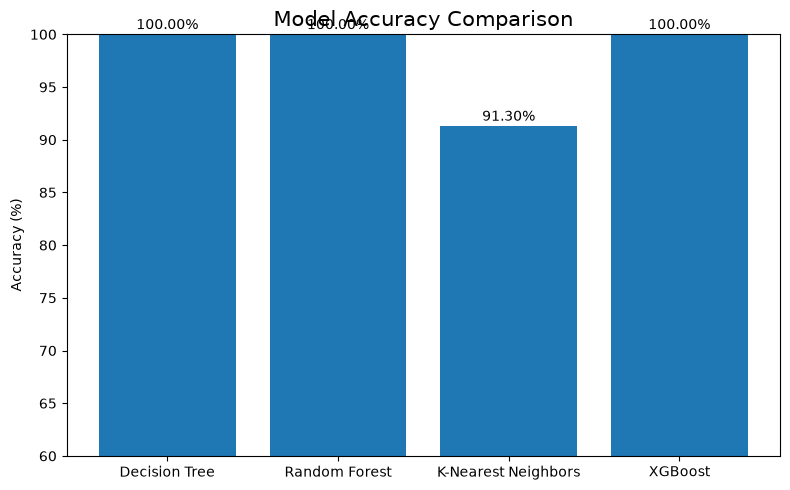

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison["Model"],
    comparison["Accuracy"]*100
)

plt.title("Model Accuracy Comparison", fontsize=15)

plt.ylabel("Accuracy (%)")

plt.ylim(60,100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.5,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig("accuracy_chart.png", dpi=300)

plt.show()

<Figure size 600x600 with 0 Axes>

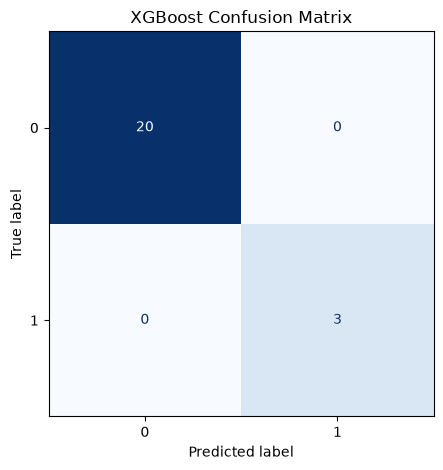

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_predictions,
    cmap="Blues",
    colorbar=False
)

plt.title("XGBoost Confusion Matrix")

plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300)

plt.show()

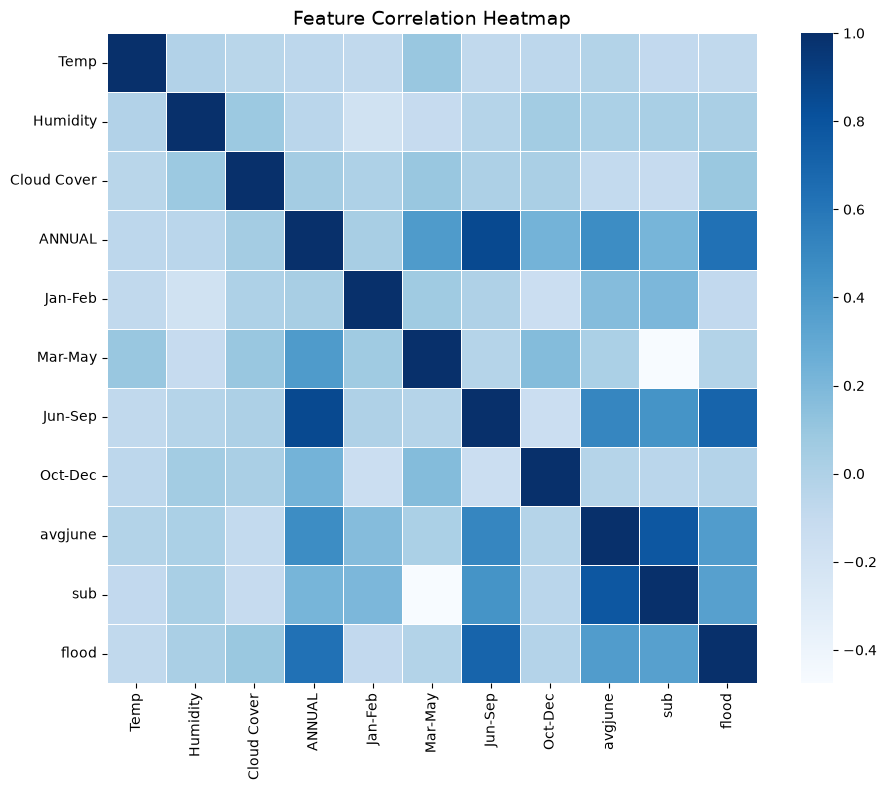

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

corr = dataset.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="Blues",
    annot=False,
    square=True,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=14)

plt.tight_layout()

plt.savefig("correlation_heatmap.png", dpi=300)

plt.show()

<Figure size 700x600 with 0 Axes>

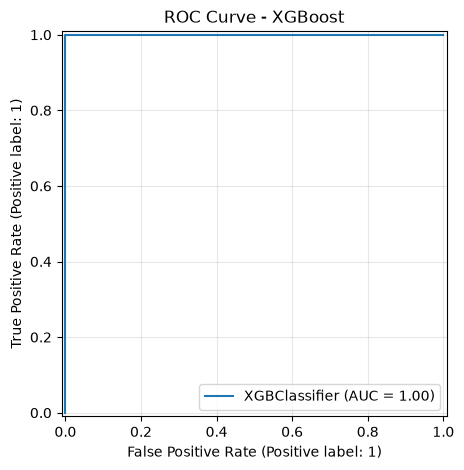

In [20]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

RocCurveDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test
)

plt.title("ROC Curve - XGBoost")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../static/images/roc_curve.png", dpi=300)

plt.show()

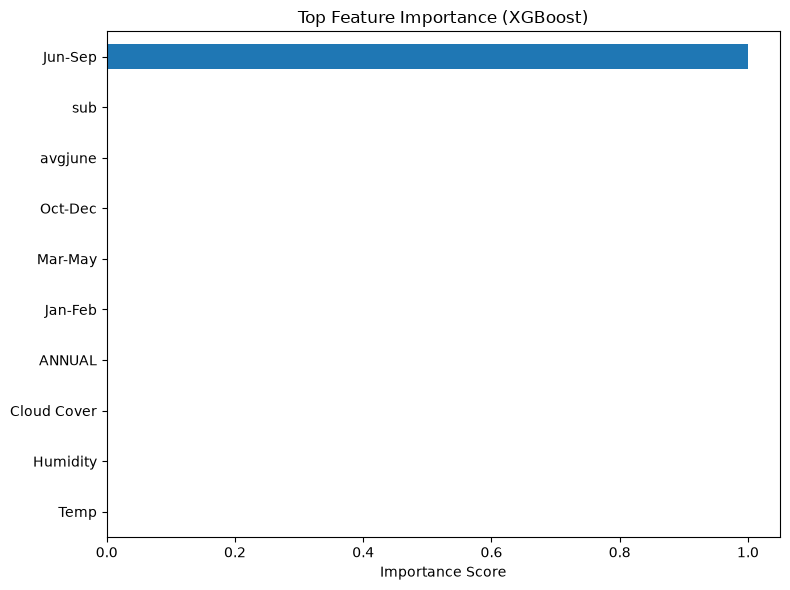

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

feature_names = dataset.drop("flood", axis=1).columns

importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

plt.figure(figsize=(8,6))
importance.plot(kind="barh")

plt.title("Top Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()

plt.savefig("../static/images/feature_importance.png", dpi=300)
plt.show()

# Step 11: Select the Best Model

The best-performing model is selected based on the highest accuracy score obtained during evaluation.

Selecting the model using actual performance ensures that the deployment is based on objective evaluation rather than assumptions.

In [21]:
best_model = xgb_model
best_model_name = "XGBoost"
best_accuracy = xgb_accuracy

print(f"Best Model : {best_model_name}")
print(f"Accuracy   : {best_accuracy:.4f}")

Best Model : XGBoost
Accuracy   : 1.0000


# Step 12: Save the Final Model

After evaluating all machine learning models, the XGBoost model was selected for deployment because it achieved the highest prediction accuracy.

To avoid retraining the model every time the application runs, the trained model is saved using the Joblib library.

The fitted StandardScaler is also saved so that user inputs during prediction can be transformed using the same scaling parameters applied during model training.

Saving both the model and scaler ensures consistent and reliable predictions during deployment.

In [22]:
import joblib
import os

In [23]:
os.makedirs("../models", exist_ok=True)

In [24]:
# Save trained XGBoost model
joblib.dump(best_model, "../models/floods.save")

# Save fitted StandardScaler
joblib.dump(scaler, "../models/scaler.save")

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


# Final Conclusion

In this notebook, multiple supervised machine learning algorithms were trained and evaluated for flood prediction, including Decision Tree, Random Forest, K-Nearest Neighbors (KNN), and XGBoost.

Each model was assessed using standard evaluation metrics such as Accuracy Score, Confusion Matrix, and Classification Report. The comparative analysis demonstrated that XGBoost achieved the best overall performance and was therefore selected as the final prediction model.

The trained XGBoost model and the fitted StandardScaler were successfully saved using Joblib, enabling efficient deployment without retraining the model each time.

This completes the machine learning model training pipeline and prepares the project for the next phase, where the saved model will be integrated into a Flask web application to perform real-time flood prediction based on user inputs.

**Outcome:**
- Multiple classification models successfully trained.
- Model performance evaluated and compared.
- XGBoost selected as the final deployment model.
- Trained model and scaler saved for future predictions.
- Project is deployment-ready for Flask integration.

---
**End of Epic 4 – Model Training and Evaluation**